In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
import matplotlib.dates as mdates
from scipy.optimize import basinhopping

from scipy import stats

from statsmodels.tools.numdiff import approx_hess

In [2]:
import warnings
warnings.resetwarnings()
warnings.simplefilter("default")

In [3]:
plt.rcParams['font.family']='Arial'

plt.rc('axes', labelsize=10)
plt.rc('xtick', labelsize=10) 
plt.rc('ytick', labelsize=10) 
plt.rc('legend', fontsize=10)
plt.rc('figure', titlesize=12) 
set_dpi=600

In [20]:
savefolder='../figure'

## Data

In [6]:
data_ori = pd.read_excel("../data/Final_heat_region.xlsx")
data_ori["date"] = pd.to_datetime(data_ori["date"], errors="raise")

data_p2 = data_ori.loc[data_ori["date"].dt.year.between(2016, 2023)].copy()
data_p2["year"] = data_p2["date"].dt.year
data_p2.reset_index(drop=True, inplace=True)

if data_p2[["date", "region"]].isna().any().any() or data_p2.duplicated(["date", "region"]).any(): raise ValueError("Missing or duplicate date-region keys were found.")
for col in ["case", "wbgt"]: data_p2[col] = pd.to_numeric(data_p2[col], errors="raise")
observed_cases = data_p2["case"].dropna().to_numpy(float)
if not np.isfinite(observed_cases).all() or np.any(observed_cases < 0) or not np.allclose(observed_cases, np.rint(observed_cases), rtol=0, atol=1e-8): raise ValueError("Observed case counts must be finite, non-negative integers.")

In [7]:
national_source = data_p2.loc[np.isfinite(data_p2["case"]) & np.isfinite(data_p2["wbgt"])].copy()
n_regions = data_p2["region"].nunique()

complete_dates = national_source.groupby("date")["region"].nunique()
national_source = national_source.loc[national_source["date"].isin(complete_dates.index[complete_dates.eq(n_regions)])]
data_loc2 = national_source.groupby("date", as_index=False).agg(case=("case", "sum"), wbgt=("wbgt", "max"))
data_loc2["year"] = data_loc2["date"].dt.year

## Hockey stick model

In [ ]:
def hockey_stick(x, x0, b1, b2):
    x = np.asarray(x, dtype=float)
    return np.where(x < x0, b1, b2 * (x - x0) + b1)

def log_likelihood(params, x, y):
    y = np.asarray(y, dtype=float)
    if not np.isfinite(y).all() or np.any(y < 0) or not np.allclose(y, np.rint(y), rtol=0, atol=1e-8): raise ValueError("Poisson response values must be finite, non-negative integers.")
    mu = hockey_stick(x, *params)
    if np.any(~np.isfinite(mu)) or np.any(mu <= 0): return np.inf
    return -np.sum(stats.poisson.logpmf(np.rint(y), mu))

def get_initial_params(data):
    x, y = data["wbgt"].to_numpy(float), np.rint(data["case"].to_numpy(float))
    if not np.isfinite(x).all() or not np.isfinite(y).all() or len(x) < 10 or np.ptp(x) == 0 or y.sum() <= 0: raise ValueError("The fitting data are invalid or contain insufficient information.")
    t = float(np.median(x))
    b = max(float(y[x <= t].mean()), 0.05)
    dx = np.maximum(x - t, 0)
    if dx @ dx <= 0: raise ValueError("Insufficient data above the initial threshold.")
    s = max(float(dx @ (y - b) / (dx @ dx)), 0.01)
    return np.array([t, b, s])

def check_fit(result, data):
    if not result.lowest_optimization_result.success or not np.isfinite(result.fun) or not np.isfinite(result.x).all(): 
        raise RuntimeError("Optimization failed: do not use the fitted results or confidence intervals.")
    t, b, s = result.x
    if min(t - data["wbgt"].min(), data["wbgt"].max() - t) < 1e-4 or b <= 1e-7 or s <= 1e-7: raise RuntimeError(f"Unstable fit near a parameter boundary: {result.x}")

In [9]:
def make_positive_semidefinite(cov, eps=1e-10):
    cov = (cov + cov.T) / 2
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    eigenvalues = np.maximum(eigenvalues, eps)
    return eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T

def parametric_hockey_ci(data, x_grid, fitted_params, n_boot=5000, confidence=0.95, slope_bounds=(0, None), random_state=42):
    work = data[["wbgt", "case"]].dropna().copy()
    x = work["wbgt"].to_numpy(dtype=float)
    y = np.rint(work["case"].to_numpy(float)).astype(np.int64)
    x_grid = np.asarray(x_grid, dtype=float)
    fitted_params = np.asarray(fitted_params, dtype=float)

    hessian = approx_hess(fitted_params, lambda params: log_likelihood(params, x, y))
    covariance = make_positive_semidefinite(np.linalg.pinv(hessian))
    
    rng = np.random.default_rng(random_state)
    parameter_draws = []
    curve_draws = []
    attempts = 0
    max_attempts = n_boot * 20
    lower, upper = slope_bounds

    while len(parameter_draws) < n_boot and attempts < max_attempts:
        attempts += 1
        params = rng.multivariate_normal(mean=fitted_params, cov=covariance)
        x0, b1, b2 = params

        if not (x.min() <= x0 <= x.max()):
            continue
        if b1 <= 0:
            continue
        if lower is not None and b2 < lower:
            continue
        if upper is not None and b2 > upper:
            continue

        mu_observed = hockey_stick(x, *params)
        curve = hockey_stick(x_grid, *params)
        if (np.any(~np.isfinite(mu_observed)) or np.any(mu_observed <= 0) or
                np.any(~np.isfinite(curve)) or np.any(curve <= 0)):
            continue

        parameter_draws.append(params)
        curve_draws.append(curve)

    if len(parameter_draws) < n_boot:
        raise RuntimeError(
            f"Failed to obtain {n_boot} valid parametric draws. "
            f"Successful draws: {len(parameter_draws)}, attempts: {attempts}"
        )
    
    parameter_draws = np.asarray(parameter_draws)
    curve_draws = np.asarray(curve_draws)
    alpha = 1 - confidence
    q = [100 * alpha / 2, 100 * (1 - alpha / 2)]

    return {
        "parameter_draws": parameter_draws,
        "curve_draws": curve_draws,
        "parameter_ci": np.percentile(parameter_draws, q, axis=0),
        "curve_lower": np.percentile(curve_draws, q[0], axis=0),
        "curve_upper": np.percentile(curve_draws, q[1], axis=0),
        "covariance": covariance,
        "hessian": hessian,
        "n_draws": len(parameter_draws)
    }

In [10]:
data_loc2_drop = data_loc2.dropna(subset=["date", "case", "wbgt"]).reset_index(drop=True).copy()

In [11]:
tmp = data_loc2_drop[["wbgt", "case"]].copy()
x = tmp["wbgt"].to_numpy(float)
y = tmp["case"].to_numpy(float)

non_integer = ~np.isclose(y, np.round(y), atol=1e-10)

if np.any(non_integer):
    bad_values = y[non_integer]

    raise ValueError("'case' must contain integer counts. "
        f"Non-integer values were found: {bad_values[:10]}"
    )

y = y.astype(int)

x0_init = np.median(x)

below = x < x0_init
b1_init = np.mean(y[below]) if np.any(below) else np.mean(y)
b1_init = max(float(b1_init), 1e-6)

above = x >= x0_init 

if np.sum(above) >= 2 and np.ptp(x[above]) > 0: 
    b2_init = np.polyfit(x[above] - x0_init, y[above], deg=1)[0] 
else:
    b2_init = 0.1

b2_init = max(float(b2_init), 1e-6)

initial_params = np.array([x0_init, b1_init, b2_init],dtype=float)

print(
    f"Initial values: "
    f"x0={x0_init:.3f}, "
    f"b1={b1_init:.3f}, "
    f"b2={b2_init:.3f}"
)

Initial values: x0=29.920, b1=2.401, b2=16.120


# Region data

## metro / urban

In [12]:
data_region=data_p2.copy()

In [13]:
metro_data=pd.DataFrame([],columns=['date','case','wbgt'])
urban_data=pd.DataFrame([],columns=['date','case','wbgt'])

In [14]:
tmp_data = data_region.loc[data_region["metro"].eq(1)].dropna(subset=["date", "case", "wbgt"])
metro_data = tmp_data.groupby("date", as_index=False).agg(case=("case", "sum"), wbgt=("wbgt", "max"))

tmp_data = data_region.loc[data_region["metro"].eq(0)].dropna(subset=["date", "case", "wbgt"])
urban_data = tmp_data.groupby("date", as_index=False).agg(case=("case", "sum"), wbgt=("wbgt", "max"))

In [15]:
resultm_list=[]
ym_fit_list=[]
metro_data_drop=metro_data.dropna()
urban_data_drop=urban_data.dropna()

for group_index, x in enumerate([metro_data_drop, urban_data_drop]):
    tmp=x
    minimizer_kwargs={"method":"SLSQP",
        # "method":"Nelder-Mead",
        "bounds": ((tmp["wbgt"].min(), tmp["wbgt"].max()), (1e-8, None), (0, None)),
        "args":(tmp['wbgt'],tmp['case'])}
    
    resultm = basinhopping(log_likelihood, get_initial_params(tmp), minimizer_kwargs=minimizer_kwargs, niter=1000, niter_success=100, seed=42)
    check_fit(resultm, tmp)
    th1,b1,b2=resultm.x
    
    x_fit_metro=np.linspace(21,38,100)
    ym_fit=hockey_stick(x_fit_metro,th1,b1,b2)
    ym_fit_list.append(ym_fit)
    resultm_list.append(resultm.x)
    
    print(resultm.x)

c:\Python\Lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Python\Lib\site-packages\scipy\optimize\_slsqp_py.py:441: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)


[30.88805805  0.73311363  4.56399487]
[29.93365046  2.20987678 11.04484576]


## by region

In [16]:
x_fit=np.linspace(21,38,100)

In [17]:
region_cap_name=['Seoul', 'Gyeonggi', 'Incheon', 'Chungbuk', 'Chungnam', 'Daejeon', 'Jeonbuk', 'Jeonnam', 'Gwangju', 'Jeju', 'Gangwon', 'Gyeongbuk', 'Daegu', 'Gyeongnam', 'Ulsan', 'Busan']
Region_code=['G1','G2','G3','G4','G5','G6','G7','G8','G9','G10', 'G11','G12','G13','G14','G15','G16']

In [18]:
result_region_list=[]
y_fit_region_list=[]

data_region_drop = data_region.dropna(subset=["date", "region", "case", "wbgt"]).copy()
data_region_drop.reset_index(drop=True, inplace=True)

for region_index, x in enumerate(region_cap_name):
    tmp=data_region_drop[data_region_drop['region']==x]
    minimizer_kwargs={"method":"SLSQP",
        "bounds": ((tmp["wbgt"].min(), tmp["wbgt"].max()), (1e-8, None), (0, None)),
        "args":(tmp['wbgt'],tmp['case'])}
    
    result_region = basinhopping(log_likelihood, get_initial_params(tmp), minimizer_kwargs=minimizer_kwargs, niter=1000, niter_success=100, seed=42)
    check_fit(result_region, tmp)
    th1,b1,b2=result_region.x
    
    x_fit_region=np.linspace(21,38,100)
    y_fit_region=hockey_stick(x_fit_region,th1,b1,b2)
    y_fit_region_list.append(y_fit_region)
    result_region_list.append(result_region.x)
    
    print(x,result_region.x)

Seoul [29.54372793  0.2558783   2.30162749]
Gyeonggi [29.6979431   0.71549303  4.38454263]
Incheon [27.39532942  0.13111713  1.23466548]
Chungbuk [29.11312786  0.15509598  1.03124786]
Chungnam [29.12660449  0.21798785  1.39344423]
Daejeon [29.73954598  0.0572753   0.34460176]
Jeonbuk [28.90629519  0.15217701  0.99499531]
Jeonnam [28.68641525  0.35294116  1.51664138]
Gwangju [30.23526866  0.09836769  0.4767532 ]
Jeju [26.88242299  0.07619164  0.39544918]
Gangwon [28.16837952  0.21162737  0.84421763]
Gyeongbuk [28.3070931   0.25907593  1.17562462]
Daegu [29.1152      0.03891184  0.2803363 ]
Gyeongnam [29.14814717  0.2512563   1.46416282]
Ulsan [28.36069773  0.05987056  0.34316366]
Busan [28.33256002  0.09624054  1.01184012]


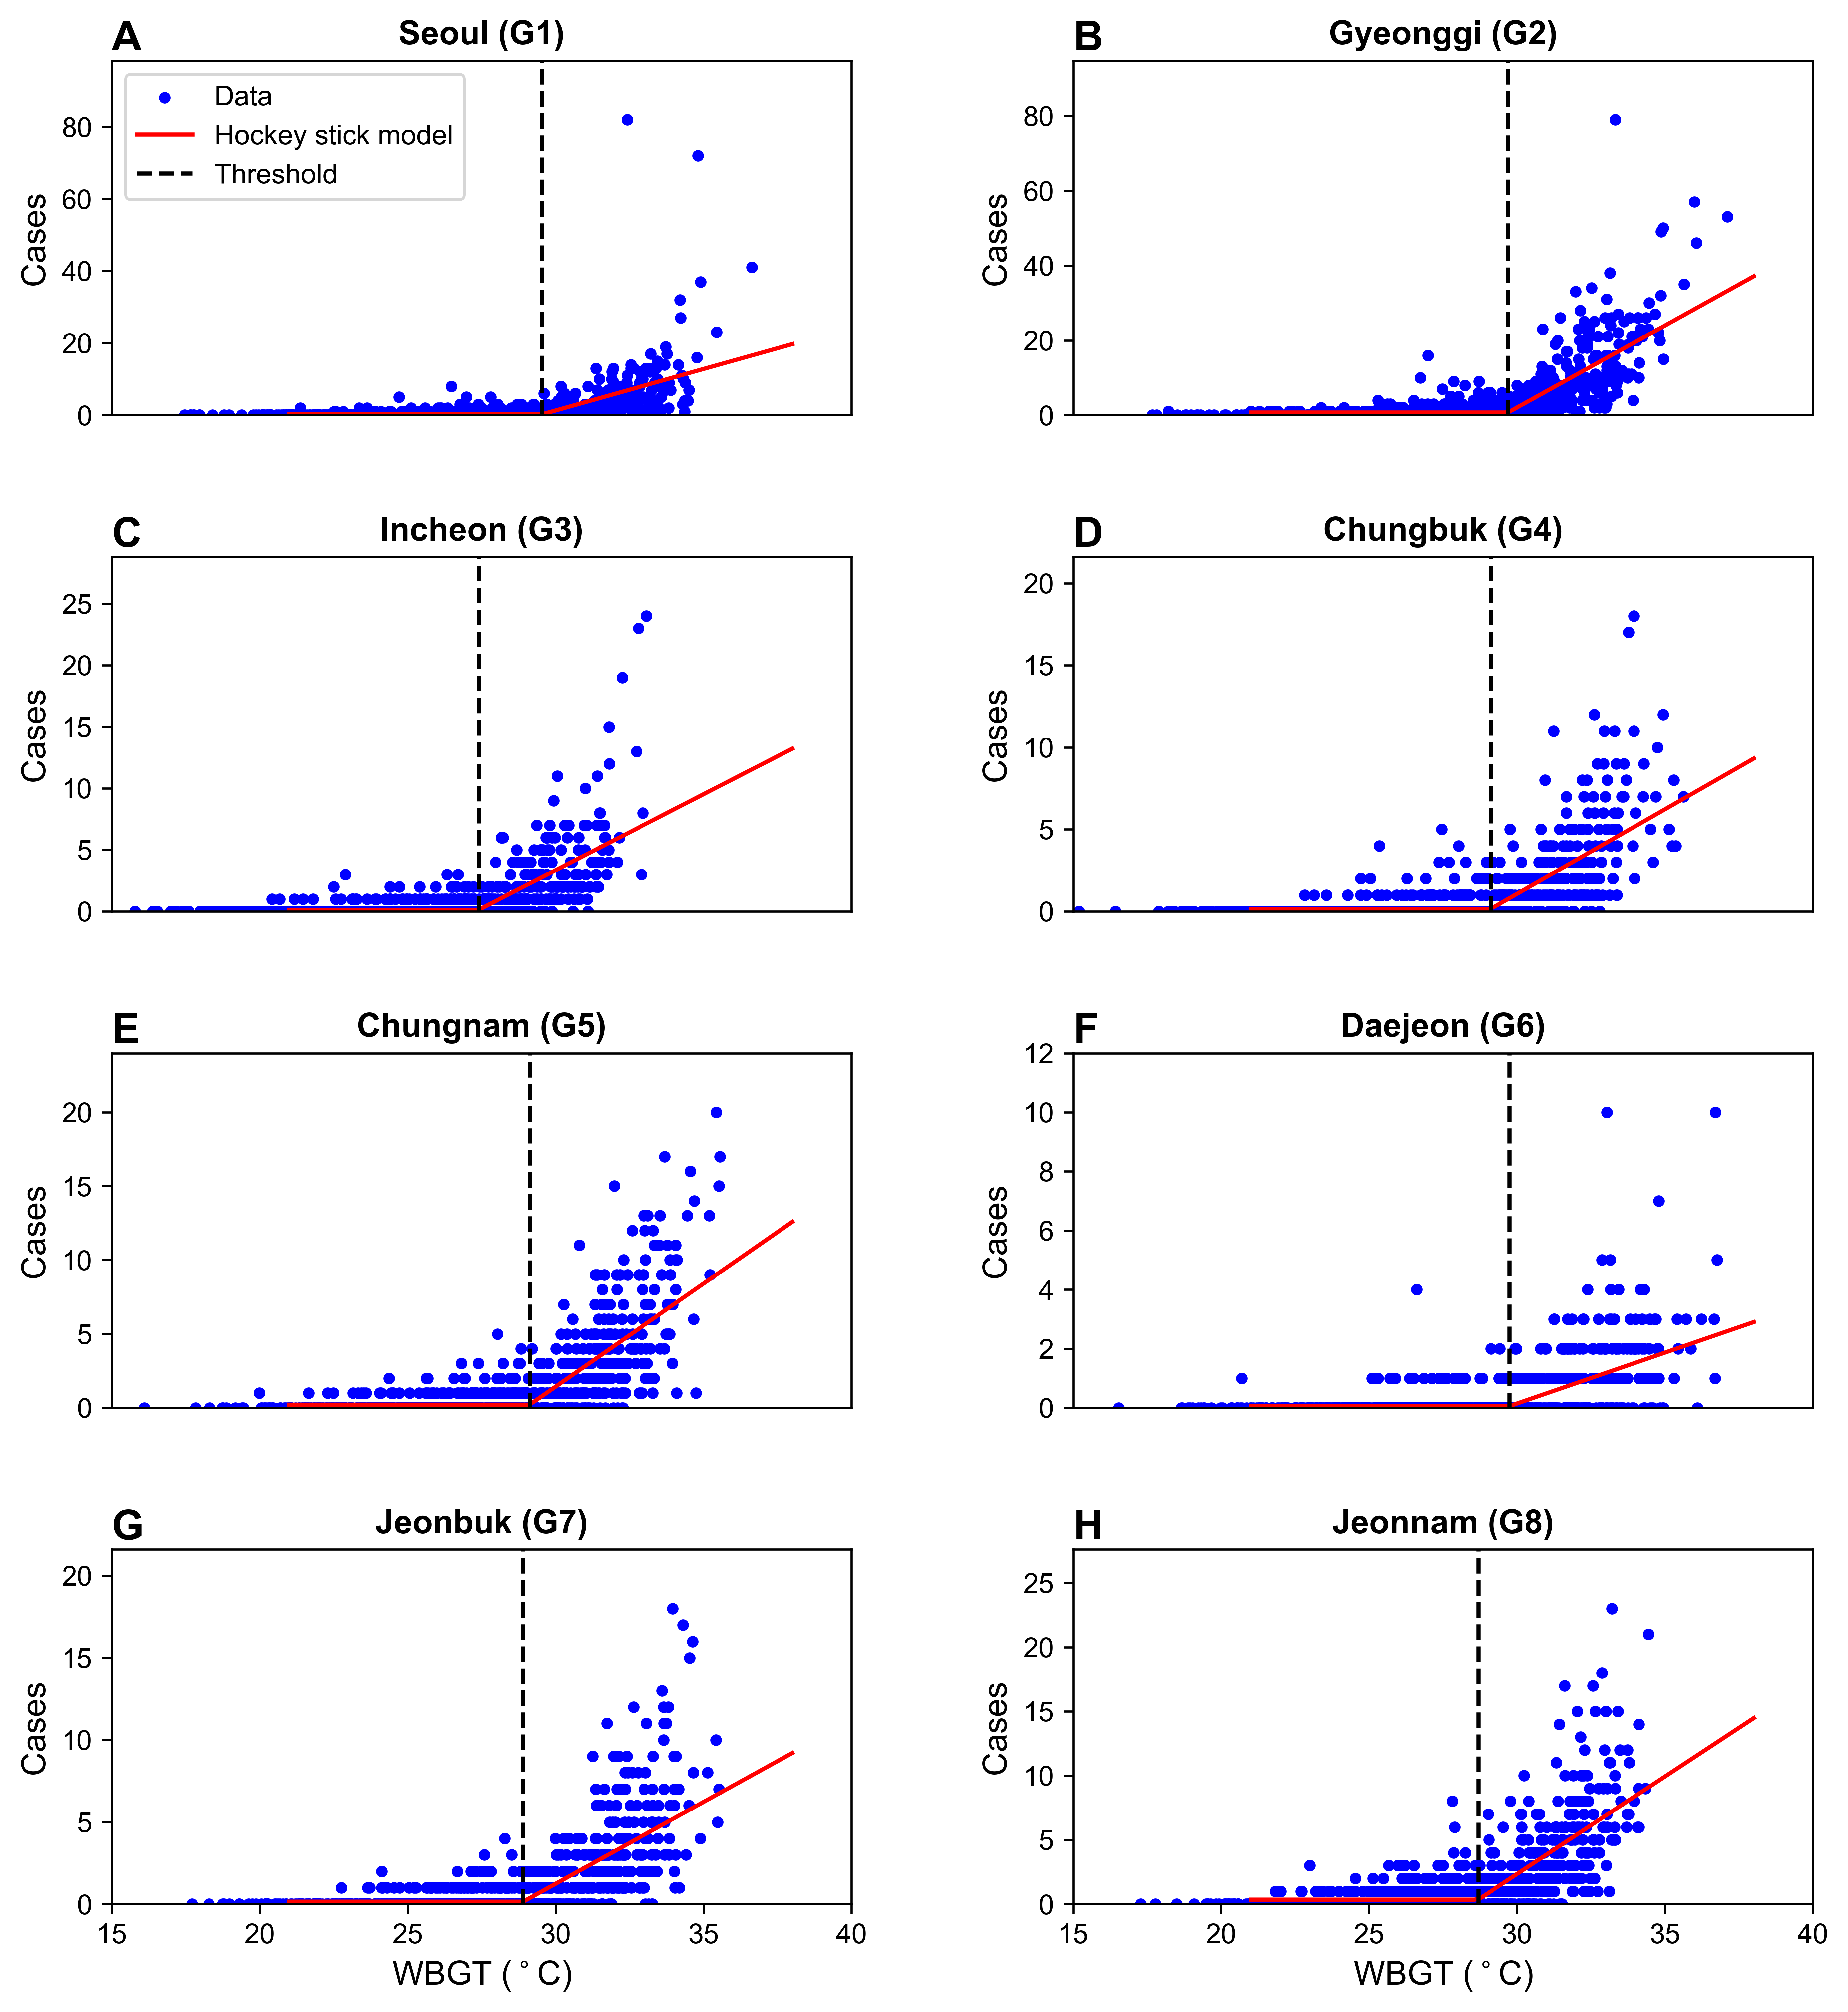

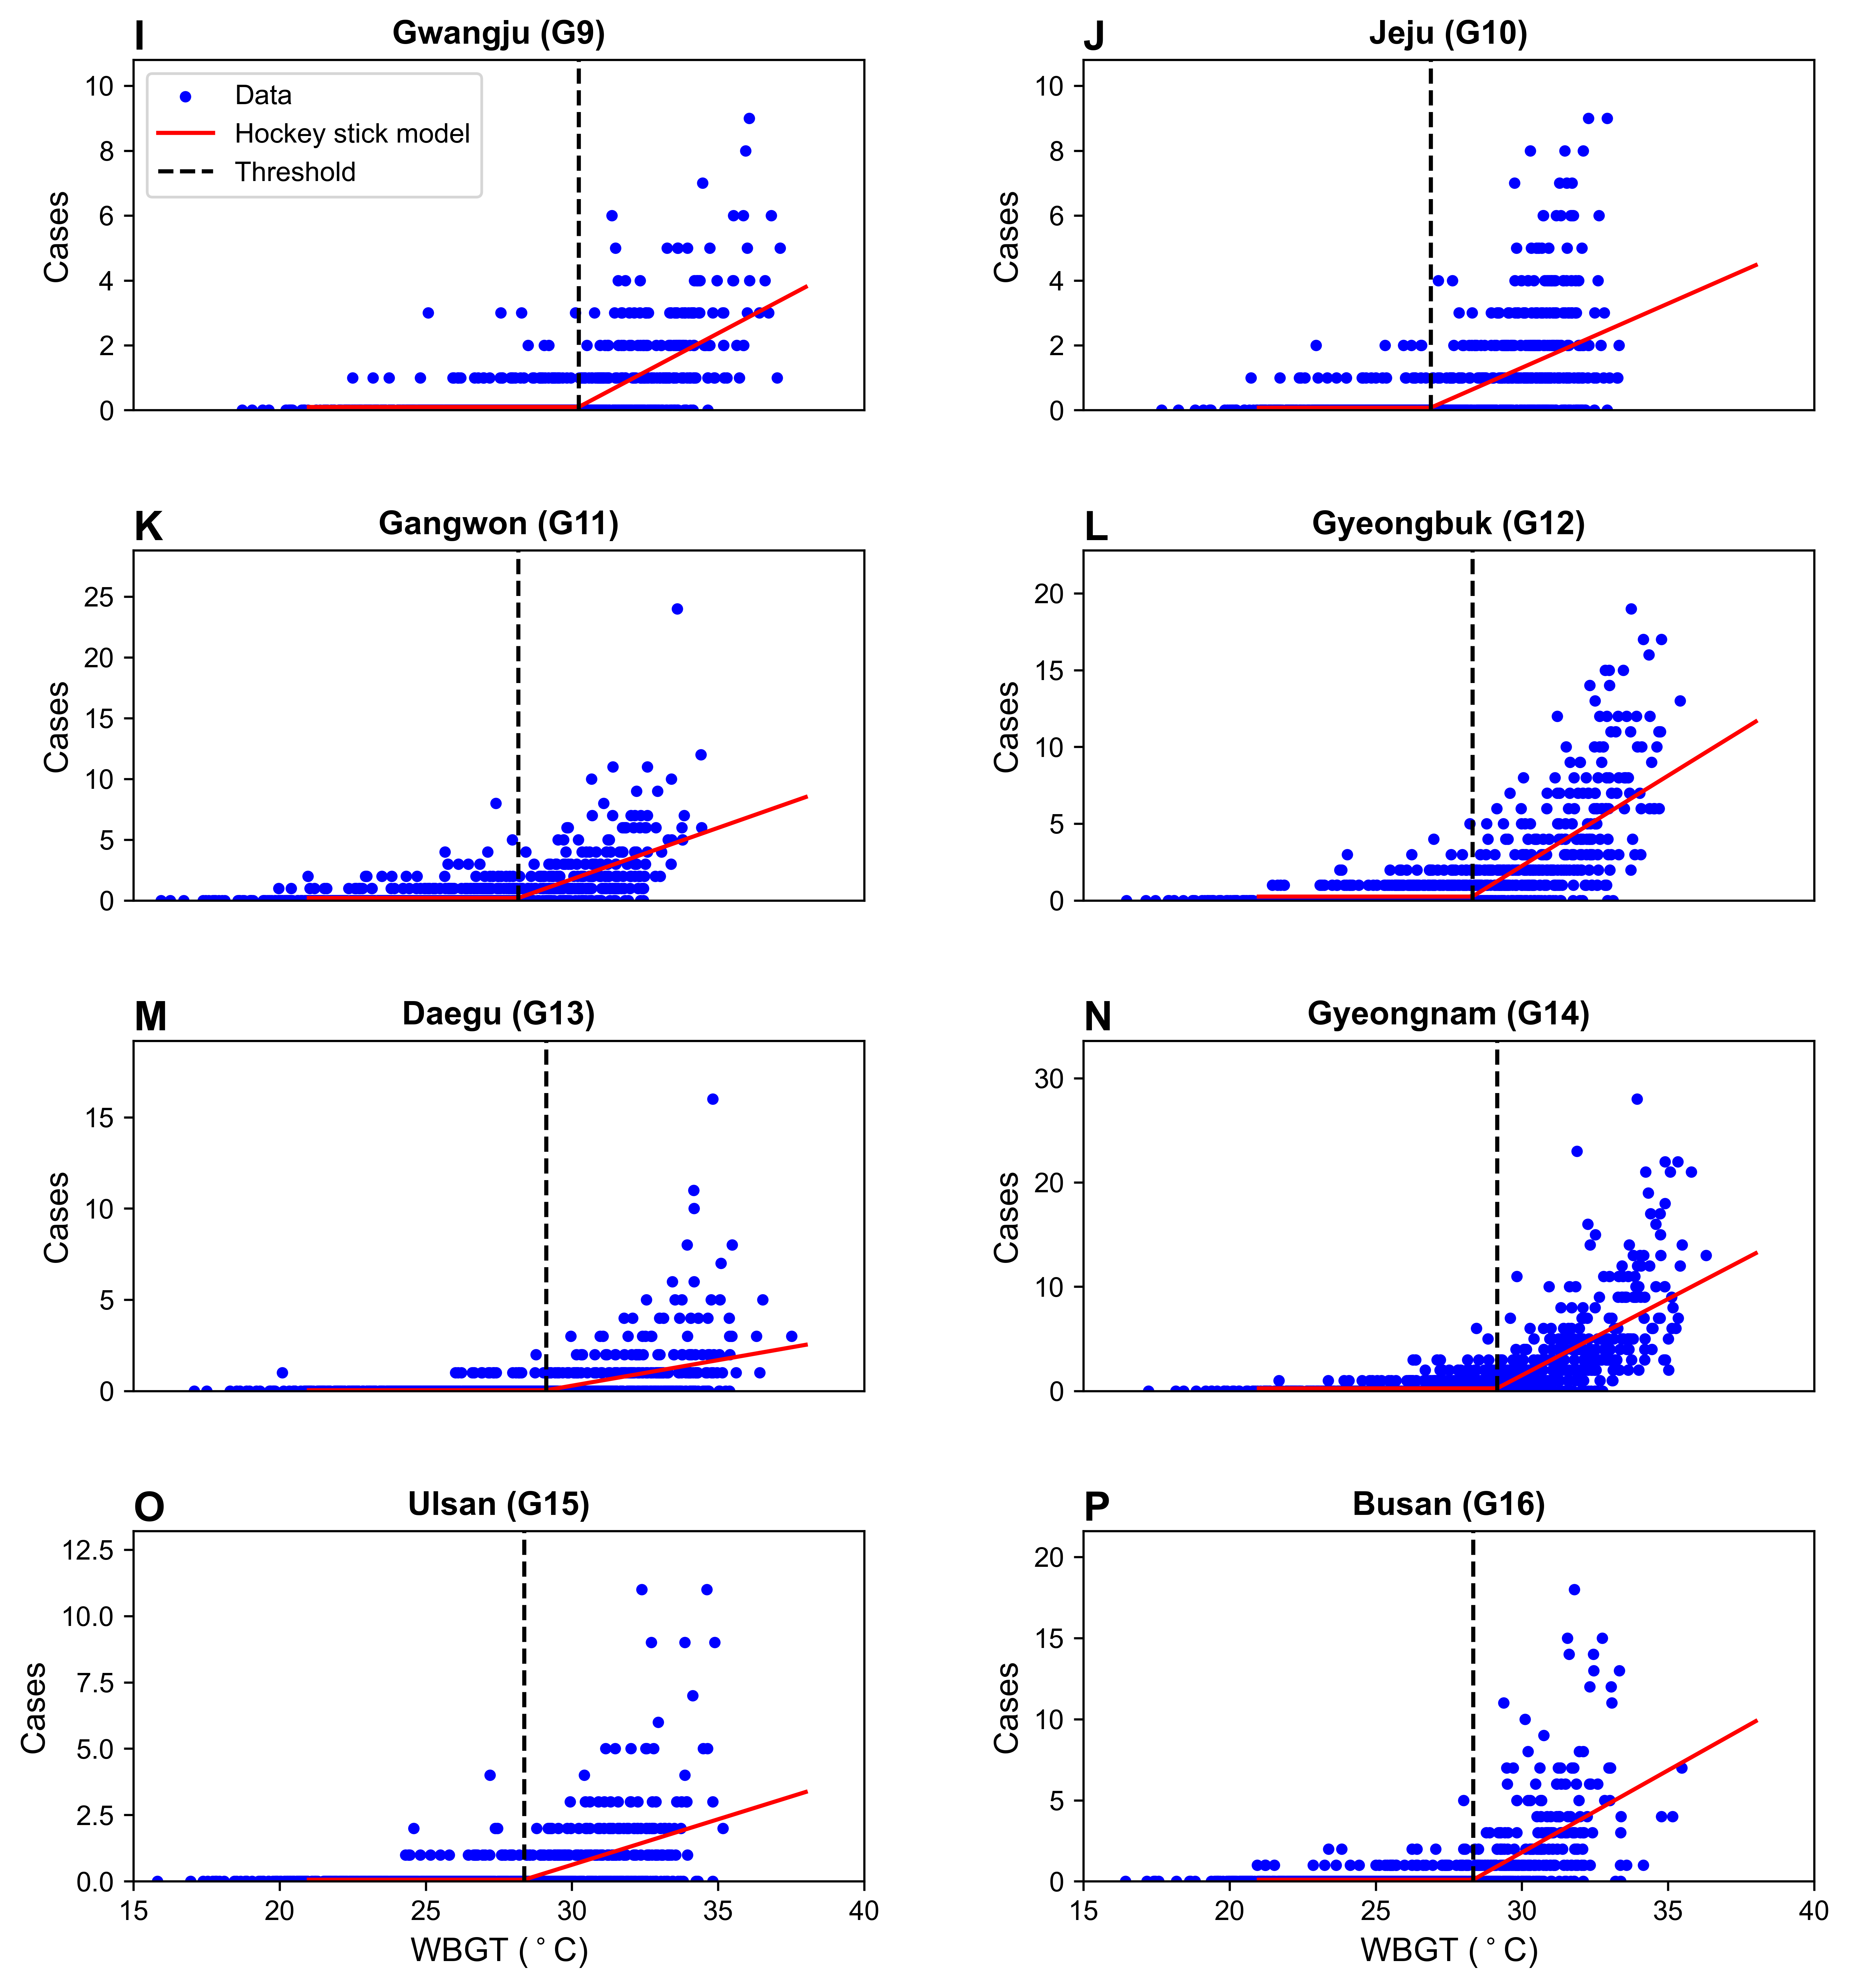

In [21]:
for start, filename in [(0, "Hockey_stick1.jpg"), (8, "Hockey_stick2.jpg")]:
    fig, ax = plt.subplots(4, 2, figsize=(11, 12), dpi=600)
    fig.subplots_adjust(hspace=0.4, wspace=0.3)

    for k, j in enumerate(range(start, start + 8)):
        row, col = divmod(k, 2)
        region, region_code = region_cap_name[j], Region_code[j]
        tmp = data_region_drop.loc[data_region_drop["region"].eq(region)]
        threshold = result_region_list[j][0]

        ax[row, col].scatter(tmp["wbgt"], tmp["case"], color="blue", s=10, label="Data")
        ax[row, col].plot(x_fit_region, y_fit_region_list[j], color="red", label="Hockey stick model")
        ax[row, col].axvline(threshold, color="black", linestyle="--", linewidth=1.5, label="Threshold")
        ax[row, col].set_title(f"{region} ({region_code})", weight="bold")
        ax[row, col].margins(0)
        ax[row, col].set_ylim(0, max(1, float(tmp["case"].max()) * 1.2))
        ax[row, col].set_xlim(15, 40)
        ax[row, col].set_ylabel("Cases", fontsize=12)
        ax[row, col].text(0, 1.03, string.ascii_uppercase[j], transform=ax[row, col].transAxes, weight="bold", fontsize=15)

        if row != 3: ax[row, col].set_xticks([])
        else: ax[row, col].set_xlabel(r"WBGT ($^\circ$C)", fontsize=12)

    ax[0, 0].legend(loc="upper left", fontsize=10)
    fig.savefig(f"{savefolder}/{filename}", bbox_inches="tight", pad_inches=0.1, dpi=set_dpi)
    plt.show()